In [1]:
import pandas as pd
from tqdm import tqdm
tqdm.pandas()

import fasttext
from utils import lemmatize
from utils import glob_val, target_proc, ft

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\acer\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
c:\Users\acer\miniconda3\envs\nlp\lib\site-packages\pymorphy2\analyzer.py:114: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Структура папок проверена


In [2]:
TRAIN_NAME_FILE = "train_ft"
VAL_NAME_FILE = "val_ft"
TEST_NAME_FILE = "test_ft"

TRAIN_NAME_FILE_NO_LEM = "train_ft_no_lem"
VAL_NAME_FILE_NO_LEM = "val_ft_no_lem"
TEST_NAME_FILE_NO_LEM = "test_ft_no_lem"

# Подготовка данных

In [3]:
X_train = pd.read_csv(f'{glob_val.X_DATA_DIR}/x_train_str.csv')
y_train = pd.read_csv(f'{glob_val.TARGET_DIR}/y_train.csv')

X_test = pd.read_csv(f'{glob_val.X_DATA_DIR}/x_test_str.csv')
y_test = pd.read_csv(f'{glob_val.TARGET_DIR}/y_test.csv')

X_val = pd.read_csv(f'{glob_val.X_DATA_DIR}/x_val_str.csv')
y_val = pd.read_csv(f'{glob_val.TARGET_DIR}/y_val.csv')

print('Колонки таргет:')
print(f'   {y_train.columns}\n')

print('Train:')
print(f'* x: {X_train.shape}')
print(f'* y: {y_train.shape}')
print('Val:')
print(f'* x: {X_val.shape}')
print(f'* y: {y_val.shape}')
print('Test:')
print(f'* x: {X_test.shape}')
print(f'* y: {y_test.shape}')

Колонки таргет:
   Index(['category_1', 'category_2', 'category_3'], dtype='object')

Train:
* x: (304703, 1)
* y: (304703, 3)
Val:
* x: (43017, 1)
* y: (43017, 3)
Test:
* x: (10755, 1)
* y: (10755, 3)


Как мы выяснили ранее из EDA *категория_2* и *категория_3* имеют экстремальный дисбаланс. Будем работать над классификацией товара в *категорию_1*

In [4]:
y_test = y_test['category_1'].to_numpy()
y_val = y_val['category_1'].to_numpy()
y_train = y_train['category_1'].to_numpy()
y_test

array([9, 0, 0, ..., 0, 2, 2], shape=(10755,))

In [5]:
index_in_class_dict, class_in_index_dict= target_proc.target_dict_load('category_1')
classes = list(class_in_index_dict.keys())

🟩 Словари таргетов загружены. Path:data/target/category_1.json


# 1 эксперемент

In [6]:
print('Старт лемматизации: ')
X_train_lem = X_train['name'].progress_apply(lemmatize).to_numpy()
X_val_lem = X_val['name'].progress_apply(lemmatize).to_numpy()
X_test_lem = X_test['name'].progress_apply(lemmatize).to_numpy()
print('🍋‍🟩 Лемметизации окончена')

Старт лемматизации: 


100%|██████████| 10755/10755 [00:02<00:00, 3633.23it/s]

🍋‍🟩 Лемметизации окончена


In [7]:
ft.file_save(X_train_lem, y_train, name=TRAIN_NAME_FILE)
ft.file_save(X_val_lem, y_train, name=VAL_NAME_FILE)
ft.file_save(X_test_lem, y_test, name=TEST_NAME_FILE)

In [8]:
path_train = f"{glob_val.FT_DIR}/{TRAIN_NAME_FILE}.txt"
path_val = f"{glob_val.FT_DIR}/{VAL_NAME_FILE}.txt"
path_test = f"{glob_val.FT_DIR}/{TEST_NAME_FILE}.txt"
print("Испольуемые для обучения наборы данных:")
print(f" * train path: {path_train}")
print(f" * train path: {path_val}")
print(f" * test path: {path_test}")

Испольуемые для обучения наборы данных:
 * train path: data/ft/train_ft.txt
 * train path: data/ft/val_ft.txt
 * test path: data/ft/test_ft.txt


Способ обработки мы изменять не будем. Поэксперементируем с гиперпараметрами модели и посмотрим на результаты

100%|██████████| 10755/10755 [00:00<00:00, 224121.05it/s]


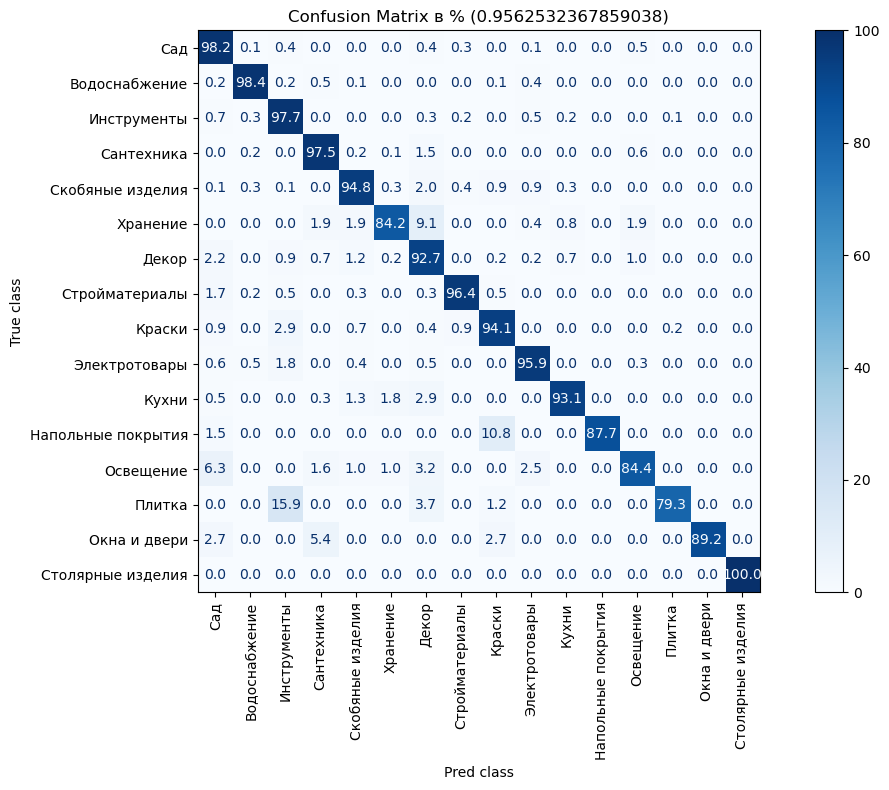

In [9]:
model = fasttext.train_supervised(
    input=path_train,
    epoch=5
) 

_ = ft.predict_and_cm_show(model, X_test_lem, y_test, classes, figsize=(12, 8))

100%|██████████| 10755/10755 [00:00<00:00, 229170.74it/s]


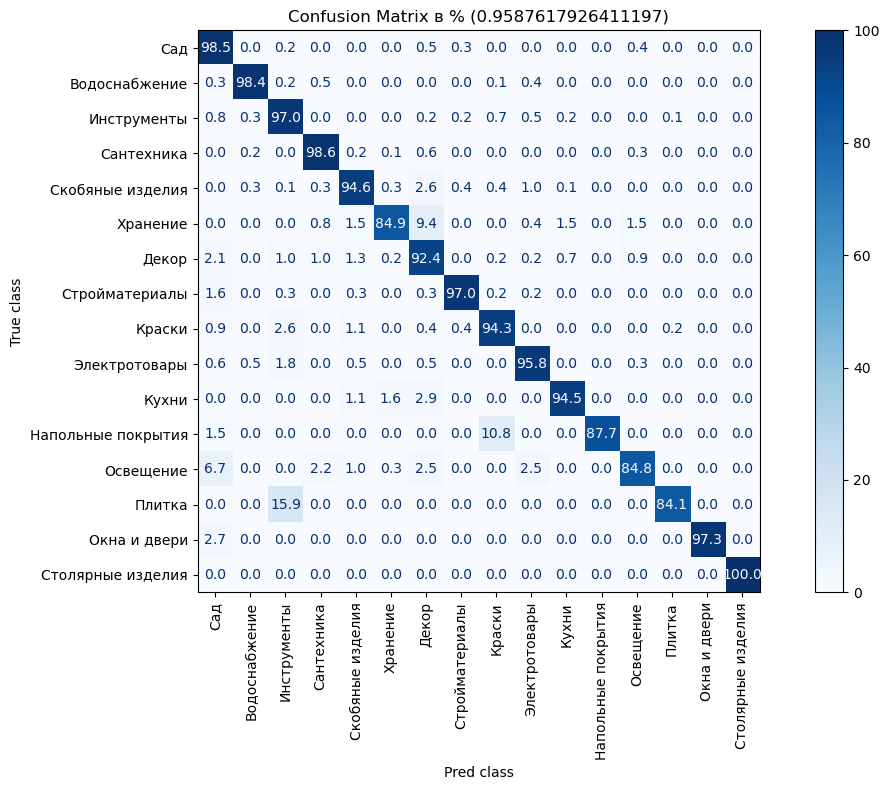

In [10]:
model = fasttext.train_supervised(
    input=path_train,
    epoch=25
) 

_ = ft.predict_and_cm_show(model, X_test_lem, y_test, classes, figsize=(12, 8))

Так же попробуем вариант с автотюном

100%|██████████| 10755/10755 [00:00<00:00, 47089.13it/s]


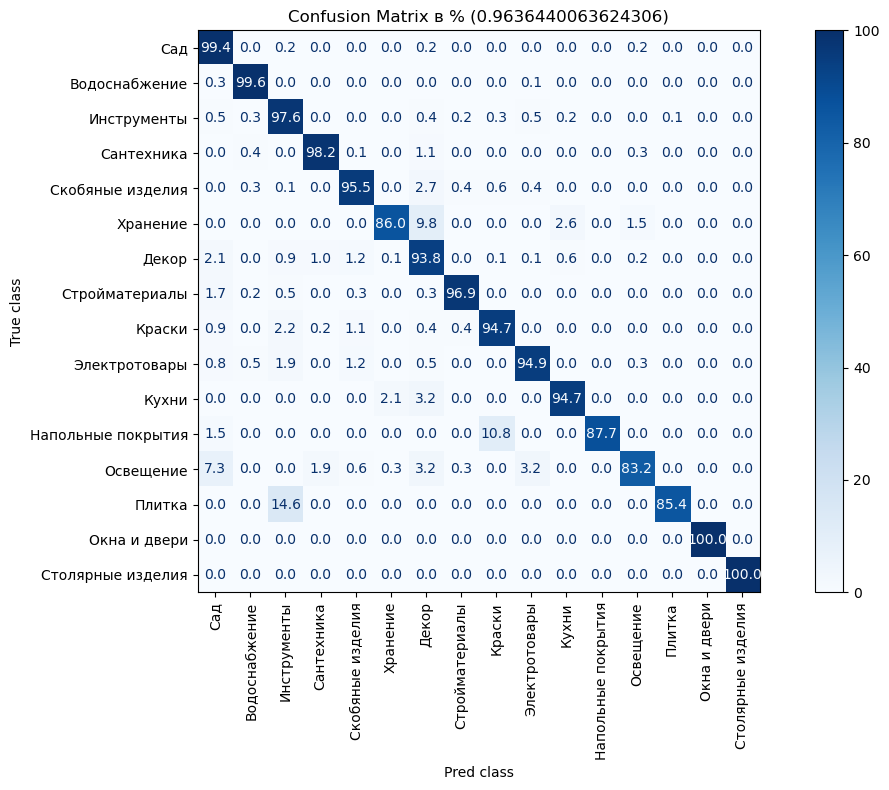

In [11]:

model = fasttext.train_supervised(
    input=path_train,
    autotuneValidationFile = path_val,
    autotuneDuration = 360,
    epoch=50
) 

_ = ft.predict_and_cm_show(model, X_test_lem, y_test, classes, figsize=(12, 8))

## 2 эксперемент

Попробуем изменить данные и юудем работать с данными без лемматизации.

In [15]:
ft.file_save(X_train.to_numpy(), y_train, name=TRAIN_NAME_FILE_NO_LEM)
ft.file_save(X_val.to_numpy(), y_val, name=VAL_NAME_FILE_NO_LEM)
ft.file_save(X_test.to_numpy(), y_test, name=TEST_NAME_FILE_NO_LEM)

In [16]:
path_train_no_lem = f"{glob_val.FT_DIR}/{TRAIN_NAME_FILE_NO_LEM}.txt"
path_val_no_lem = f"{glob_val.FT_DIR}/{VAL_NAME_FILE_NO_LEM}.txt"
path_test_no_lem = f"{glob_val.FT_DIR}/{TEST_NAME_FILE_NO_LEM}.txt"

print("Испольуемые для обучения наборы данных:")
print(f" * train path: {path_train_no_lem}")
print(f" * train path: {path_val_no_lem}")
print(f" * test path: {path_test_no_lem}")

Испольуемые для обучения наборы данных:
 * train path: data/ft/train_ft_no_lem.txt
 * train path: data/ft/val_ft_no_lem.txt
 * test path: data/ft/test_ft_no_lem.txt


100%|██████████| 10755/10755 [00:00<00:00, 93889.04it/s]


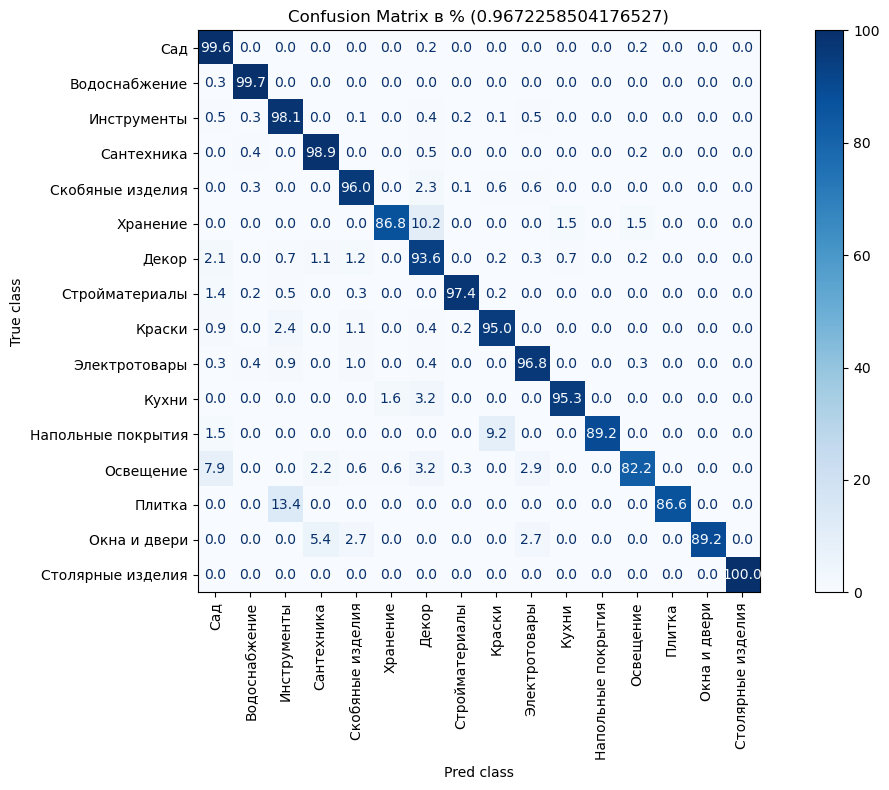

In [17]:
model = fasttext.train_supervised(
    input=path_train_no_lem,
    epoch=25,
    lr=0.01
) 

_ = ft.predict_and_cm_show(model, X_test.to_numpy(), y_test, classes, figsize=(12, 8))

100%|██████████| 10755/10755 [00:00<00:00, 151596.76it/s]


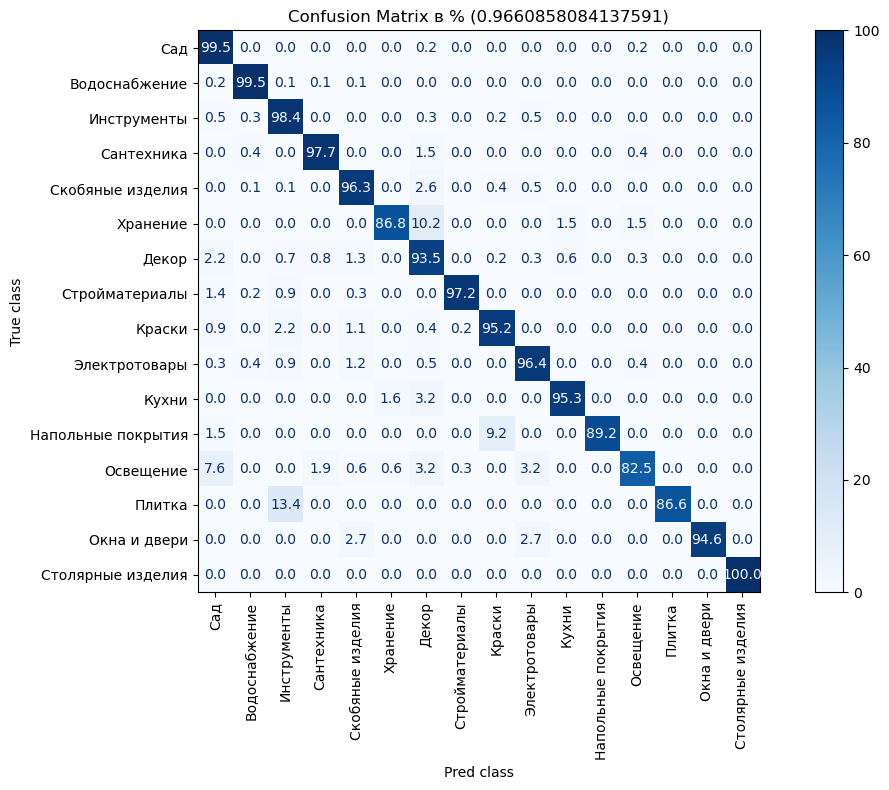

In [19]:
model = fasttext.train_supervised(
    input=path_train_no_lem,
    epoch=30,
    lr=0.01
) 

_ = ft.predict_and_cm_show(model, X_test.to_numpy(), y_test, classes, figsize=(12, 8))

Теперь попробуем использовать n-gramm

100%|██████████| 10755/10755 [00:00<00:00, 12565.54it/s]


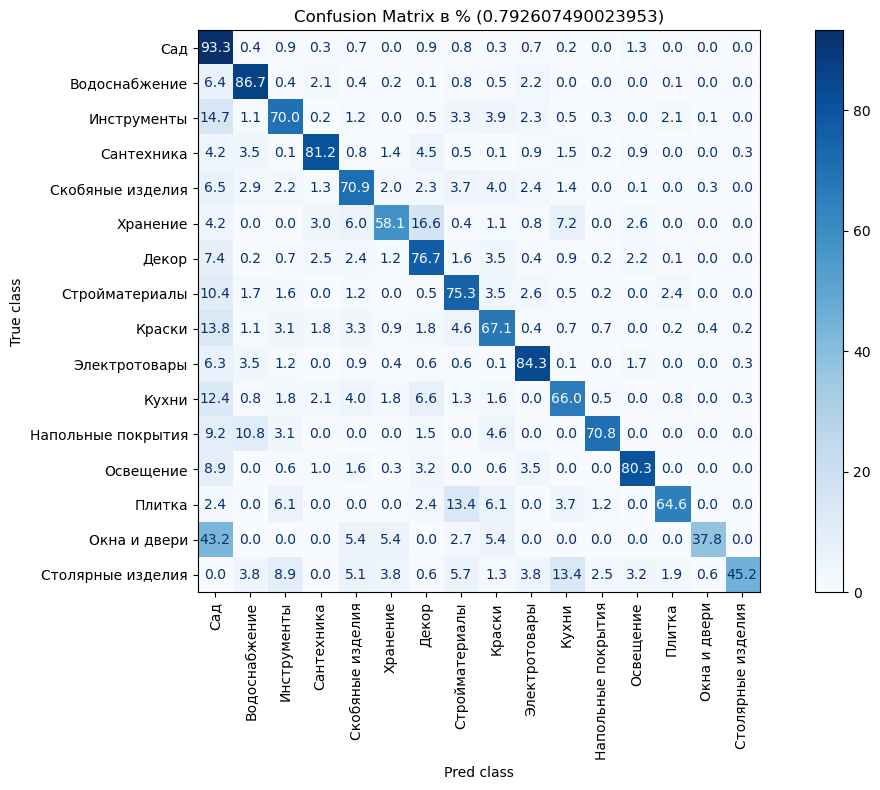

In [20]:
model = fasttext.train_supervised(
    input=path_train_no_lem,
    autotuneValidationFile = path_val_no_lem,
    autotuneDuration = 360,
    epoch=50
) 

_ = ft.predict_and_cm_show(model, X_test_lem, y_test, classes, figsize=(12, 8))

Плохо решила нашу задача модель с автоподбором